# Telco Customer Churn：契約・料金・利用期間と解約の関連

日本語の観測データ分析。run_id: `v020-exp-43`。指定Kaggle公開データのみを使用し、個人の解約原因・契約変更の効果は識別しない。認証情報は記録しない。

## 分析計画
クラス比率と意味的品質を確認し、カテゴリを名義変数として符号化する。粗関連と顧客期間別関連・調整モデルを比較する。層化ホールドアウトで予測関連を評価し、限定された仕様感度分析を行う。初回結果を読んで必要な反復だけ追加する。全コードの上から再実行とvisual_audit=True監査を最終条件とする。

In [1]:
from pathlib import Path
import os, sys, json, hashlib, io, contextlib, zipfile, re, warnings
from datetime import datetime, timezone, timedelta
from dataclasses import asdict
ROOT = Path('/home/nahisaho/GitHub/jupytermind')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(ROOT / 'benchmark/projects')
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display
from ai_data_scientist import project_manager as pm, lifecycle, language_router
from ai_data_scientist import ingestion, cleaning, eda, stats_analysis
from ai_data_scientist import data_definition as dd, analysis_assumptions as aa
from ai_data_scientist import data_quality as dq, sensitivity, visualization, notebook_audit, insight_engine
RUN_ID = 'v020-exp-43'
handle = pm.resolve_project('kaggle-v020-kaggle-exp-43-customer-churn')
pm.ensure_notebook(handle)
data_dir = pm.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
lifecycle_log = []
@contextlib.contextmanager
def phase(name):
    if lifecycle.is_cancel_requested(RUN_ID):
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('キャンセル要求により中断')
    lifecycle.mark_execution_start(RUN_ID)
    lifecycle_log.append({'phase': name, 'event': 'execution_start', 'utc': datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        lifecycle_log.append({'phase': name, 'event': 'failed'})
        raise
    finally:
        lifecycle.mark_execution_end(RUN_ID)
        lifecycle_log.append({'phase': name, 'event': 'execution_end', 'utc': datetime.now(timezone.utc).isoformat()})
def notebook_write(mutation):
    lifecycle.mark_write_start(RUN_ID)
    lifecycle_log.append({'phase': 'notebook', 'event': 'write_start'})
    try:
        return pm.enqueue_write(handle, mutation)
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        raise
    finally:
        lifecycle.mark_write_end(RUN_ID)
        lifecycle_log.append({'phase': 'notebook', 'event': 'write_end'})
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
print('言語:', language_router.detect_language('解約分析の日本語報告'))
print('run_id:', RUN_ID)
print('ライフサイクル:', asdict(lifecycle.get_run_status(RUN_ID)))


言語: ja
run_id: v020-exp-43
ライフサイクル: {'run_id': 'v020-exp-43', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-43-customer-churn/notebooks/kaggle-v020-kaggle-exp-43-customer-churn.ipynb', 'reason': None}


## Kaggle取得と来歴
公開データ検索・公式ファイル一覧・ファイル取得をインストール済みPython SDKで実施。SDKの認証出力と例外本文は表示しない。取得失敗時だけ指定white-paper.mdを確認し、同一CSVの明記されたURL以外には代替しない。

In [2]:
with phase('Kaggle公開データ検索・取得'):
    acquisition_log = []
    kaggle_failure = None
    # 認証SDKの標準出力・標準エラーと例外本文を表示しない。
    try:
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            from kaggle.api.kaggle_api_extended import KaggleApi
            api = KaggleApi()
            api.authenticate()
            found = api.dataset_list(search='telco customer churn')
            listing = api.dataset_list_files('blastchar/telco-customer-churn')
        refs = [str(getattr(x, 'ref', '')) for x in found]
        files = [str(getattr(x, 'name', '')) for x in listing.files]
        acquisition_log.append({'operation': 'authenticate', 'result': '成功・認証情報非表示'})
        acquisition_log.append({'operation': 'dataset_list', 'search': 'telco customer churn', 'matching_refs': refs[:20]})
        acquisition_log.append({'operation': 'dataset_list_files', 'slug': 'blastchar/telco-customer-churn', 'files': files})
        filename = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
        if filename not in files:
            raise FileNotFoundError('指定CSVが公式ファイル一覧に存在しない')
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.dataset_download_file('blastchar/telco-customer-churn', filename, path=str(data_dir), force=True, quiet=True)
        csv_path = data_dir / filename
        if not csv_path.exists():
            zip_path = data_dir / (filename + '.zip')
            if not zip_path.exists():
                raise FileNotFoundError('SDK取得ファイルが見つからない')
            with zipfile.ZipFile(zip_path) as z:
                matching = [n for n in z.namelist() if Path(n).name == filename]
                if len(matching) != 1:
                    raise ValueError('取得ZIP内の対象CSVを一意に確認できない')
                csv_path.write_bytes(z.read(matching[0]))
        acquired_at = datetime.now(timezone.utc).isoformat()
        provenance = {'owner_dataset_slug': 'blastchar/telco-customer-churn', 'requested_url': 'https://www.kaggle.com/datasets/blastchar/telco-customer-churn', 'filename': filename, 'acquired_at_utc': acquired_at, 'acquired_at_jst': datetime.fromisoformat(acquired_at).astimezone(timezone(timedelta(hours=9))).isoformat(), 'sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(), 'method': 'Kaggle Python SDK', 'bytes': csv_path.stat().st_size}
        acquisition_log.append({'operation': 'dataset_download_file', 'result': '成功', 'filename': filename})
    except Exception as exc:
        kaggle_failure = {'error_type': type(exc).__name__, 'http_status': getattr(exc, 'status', None), 'message': 'Kaggle取得失敗。資格情報保護のため例外本文を保存しない。white-paper.md確認が必要。'}
        acquisition_log.append(kaggle_failure)
    display(pd.DataFrame(acquisition_log))
    if kaggle_failure is not None:
        lifecycle.mark_failed(RUN_ID)
        raise RuntimeError('Kaggle取得失敗。指定white-paper.mdの同一データCSVを確認するまで分析停止。')
    print(json.dumps(provenance, ensure_ascii=False, indent=2))
    ingested = ingestion.ingest(ingestion.SourceSpec(kind='csv', location=str(csv_path)), row_limit=100000)
    assert not ingested.truncated
    raw = ingested.dataframe
    print('取得形状:', raw.shape)
    print('列名:', list(raw.columns))


{
  "owner_dataset_slug": "blastchar/telco-customer-churn",
  "requested_url": "https://www.kaggle.com/datasets/blastchar/telco-customer-churn",
  "filename": "WA_Fn-UseC_-Telco-Customer-Churn.csv",
  "acquired_at_utc": "2026-10-01T23:06:40.415295+00:00",
  "acquired_at_jst": "2026-10-02T08:06:40.415295+09:00",
  "sha256": "88be4b93fbe0cc83421af1c503794c97c342eca914c1576db7c276e61d61358a",
  "method": "Kaggle Python SDK",
  "bytes": 977501
}
取得形状: (7043, 21)
列名: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,operation,result,search,matching_refs,slug,files,filename
0,authenticate,成功・認証情報非表示,NaN,NaN,NaN,NaN,NaN
1,dataset_list,NaN,telco customer churn,"[blastchar/telco-customer-churn, abdallahwagih...",NaN,NaN,NaN
2,dataset_list_files,NaN,NaN,NaN,blastchar/telco-customer-churn,[WA_Fn-UseC_-Telco-Customer-Churn.csv],NaN
3,dataset_download_file,成功,NaN,NaN,NaN,NaN,WA_Fn-UseC_-Telco-Customer-Churn.csv


## データ定義の根拠
以下は同一slugのKaggleメタデータから取得したデータ説明。公開説明に明記されない通貨・実測方法・収集時点などは推測せず未確認とする。

In [3]:
with phase('データ辞書確認'):
    sdk_compatibility_log = {'classification': 'Kaggle SDK固有', 'initial_method': 'dataset_view', 'initial_error': 'AttributeError: KaggleApiにdataset_viewが存在しない', 'workaround': 'インストール済みSDKのdataset_metadata(dataset, path)を利用', 'impact': 'CSV取得・数値分析に影響なし'}
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.dataset_metadata('blastchar/telco-customer-churn', path=str(data_dir))
    metadata_path = data_dir / 'dataset-metadata.json'
    kaggle_metadata = json.loads(metadata_path.read_text(encoding='utf-8'))['info']
    description = str(kaggle_metadata.get('description', ''))
    print('Kaggle記載のデータ説明:')
    print(description[:16000])
    print('タイトル:', kaggle_metadata.get('title'))
    print('SDK互換性ログ:', json.dumps(sdk_compatibility_log, ensure_ascii=False))


Kaggle記載のデータ説明:
### Context

"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."  [IBM Sample Data Sets]

### Content

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

**The data set includes information about:**

+ Customers who left within the last month – the column is called Churn
+ Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
+ Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
+ Demographic info about customers – gender, age range, and if they have partners and dependents

### Inspiration

To explore this type of models and learn more about the subject.

**New version from IBM:**
https://community.ibm.com/community/user/bu

## データ定義manifest・分析前提manifest・意味的異常検査
料金の通貨は不明、tenureの単位は月と推定。非負・カテゴリ集合・ID一意性・サービス未利用と補助カテゴリの列間整合を検査する。0〜72というtenure上限はこの版の分析用支持範囲であり、他データの普遍的な制約ではない。

In [4]:
with phase('意味的品質・manifest'):
    cleaning_report = cleaning.clean_dataset(raw, operation='drop_duplicates')
    df = cleaning_report.dataframe.copy()
    total_text = df['TotalCharges'].astype(str).str.strip()
    invalid_total = pd.to_numeric(total_text, errors='coerce').isna() & total_text.ne('')
    assert not invalid_total.any(), '空白以外のTotalCharges数値変換失敗'
    df['TotalCharges'] = pd.to_numeric(total_text, errors='coerce')
    assert df['Churn'].isin(['No', 'Yes']).all()
    df['churn'] = df['Churn'].map({'No': 0, 'Yes': 1}).astype(int)
    df['monthly10'] = df['MonthlyCharges'] / 10
    df['tenure_band'] = pd.cut(df.tenure, [-1, 0, 12, 24, 48, 72], labels=['0', '1-12', '13-24', '25-48', '49-72'])
    yes_no = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']
    internet_addons = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
    category_domains = {k: ['No', 'Yes'] for k in yes_no}
    category_domains.update({k: ['No', 'Yes', 'No internet service'] for k in internet_addons})
    category_domains.update({'gender': ['Female','Male'], 'SeniorCitizen': [0,1], 'MultipleLines': ['No','Yes','No phone service'], 'InternetService': ['DSL','Fiber optic','No'], 'Contract': ['Month-to-month','One year','Two year'], 'PaymentMethod': ['Electronic check','Mailed check','Bank transfer (automatic)','Credit card (automatic)']})
    schema = {k: {'allowed': v, 'not_null': True} for k,v in category_domains.items()}
    schema.update({'customerID': {'unique': True,'not_null': True}, 'tenure': {'min':0,'max':72,'not_null':True}, 'MonthlyCharges': {'min':0,'not_null':True}, 'TotalCharges': {'min':0,'not_null':True}})
    assert set(raw.columns) == set(schema), '必須列・予期しない列の確認'
    semantic_anomalies = dq.detect_anomalies(df, schema)
    cross_checks = {
        'tenure_noninteger': int((df.tenure % 1 != 0).sum()),
        'missing_TotalCharges': int(df.TotalCharges.isna().sum()),
        'missing_TotalCharges_with_positive_tenure': int((df.TotalCharges.isna() & df.tenure.gt(0)).sum()),
        'zero_tenure_with_churn': int((df.tenure.eq(0) & df.churn.eq(1)).sum()),
        'phone_structural_mismatch': int((df.PhoneService.eq('No') != df.MultipleLines.eq('No phone service')).sum()),
        'internet_structural_mismatch': int(sum((df.InternetService.eq('No') != df[k].eq('No internet service')).sum() for k in internet_addons)),
        'duplicate_customerID': int(df.customerID.duplicated().sum())}
    print('クリーニング:', {k: v for k,v in asdict(cleaning_report).items() if k != 'dataframe'})
    print('意味的異常:', [asdict(x) for x in semantic_anomalies])
    print('列間整合性:', cross_checks)
    display(df.loc[df.TotalCharges.isna(), ['tenure','Contract','MonthlyCharges','Churn']].value_counts(dropna=False).reset_index(name='n'))
    print('観測範囲:', df[['tenure','MonthlyCharges','TotalCharges']].agg(['min','max']).to_dict())
    fields = {
        'customerID': {'definition': dd.FieldValue('顧客識別子。1行1顧客', 'verified', 'Kaggle説明・ID一意性検査')},
        'Churn': {'definition': dd.FieldValue('直近1か月に離脱した顧客', 'verified', 'Kaggle公開description'), 'encoding': dd.FieldValue('Yes=1, No=0', 'verified', 'CSVカテゴリ照合')},
        'Contract': {'definition': dd.FieldValue('現在の契約種別', 'verified', 'Kaggle説明・CSV'), 'categories': dd.FieldValue(category_domains['Contract'], 'verified', 'CSVカテゴリ検査')},
        'tenure': {'definition': dd.FieldValue('顧客としての継続期間', 'verified', 'Kaggle説明'), 'unit': dd.FieldValue('月と推定（公開descriptionでは単位未明記）', 'inferred', '列名・0-72の整数値')},
        'MonthlyCharges': {'definition': dd.FieldValue('月次請求額', 'verified', 'Kaggle説明'), 'currency': dd.FieldValue(None, 'unknown', '公開descriptionに記載なし')},
        'TotalCharges': {'definition': dd.FieldValue('累積請求額', 'verified', 'Kaggle説明'), 'currency': dd.FieldValue(None, 'unknown', '公開descriptionに記載なし'), 'missingness': dd.FieldValue('空白11件、全てtenure=0。ゼロとは断定しない', 'verified', '品質セル')}
    }
    definition_manifest = dd.build_manifest(
        source={**{k: dd.FieldValue(v, 'verified', 'Kaggle SDK取得・SHA256計算') for k,v in provenance.items()}, 'license': dd.FieldValue(kaggle_metadata.get('licenses'), 'verified', 'Kaggle metadata')},
        dataset_scope={'row_unit':dd.FieldValue('1顧客1行','verified','Kaggle説明とID一意性'), 'population':dd.FieldValue('IBM Sample Data Setsに由来する教育用データ','verified','Kaggle説明'), 'collection_date':dd.FieldValue(None,'unknown'), 'sampling_frame':dd.FieldValue(None,'unknown'), 'measurement_method':dd.FieldValue(None,'unknown')},
        variables=fields,
        transformations=('TotalCharges空白をNaNへ変換','Churn Yes=1/No=0','カテゴリ順序を仮定しない','主解析はTotalChargesを使わず全7043件を維持'))
    print('データ定義manifest:', json.dumps(asdict(definition_manifest), ensure_ascii=False, indent=2, default=str))
    print('未解決定義:', [(k,asdict(v)) for k,v in definition_manifest.unresolved_fields()])
    inferred_definitions = [(f'{col}.{key}', asdict(value)) for col, attrs in fields.items() for key,value in attrs.items() if value.status == 'inferred']
    print('推定扱いの定義:', inferred_definitions)
    assumptions = aa.AnalysisAssumptionManifest(
        analysis_scope={'target':'このCSV内の解約との関連','not_claimed':'解約原因・契約介入効果・未来月の予測性能'},
        causal_scope='associational',
        assumptions=(
            aa.Assumption('one-row', '顧客IDが一意', 'verified'),
            aa.Assumption('no-ordinal', '名義カテゴリを順序のある整数にしない', 'verified'),
            aa.Assumption('retain-missing', '主解析にTotalChargesを入れず欠損顧客も維持', 'verified'),
            aa.Assumption('model-form', '非線形tenure調整で条件付き関連を記述できる', 'assumed', impact_if_false='調整関連の大きさ・符号が変わる', conclusion_critical=True),
            aa.Assumption('representative', '実際の現在顧客母集団を代表する', 'assumed', impact_if_false='外部一般化不可', conclusion_critical=True),
            aa.Assumption('temporal', '全特徴が解約前の意思決定時点で測定されている', 'assumed', impact_if_false='前向き予測にリークのおそれ', conclusion_critical=True),
            aa.Assumption('identification', '契約・料金介入の因果効果を識別できる', 'rejected', impact_if_false='因果結論は禁止', conclusion_critical=False)))
    print('分析前提manifest:', json.dumps(asdict(assumptions),ensure_ascii=False,indent=2))
    print('前提検査所見:', [asdict(x) for x in aa.check_manifest(assumptions)])
    applicability = {'独立データ比較・validate_anomalies・compare_datasets':'別の独立データが指定・取得されていないため非適用。同じCSVのコピーを独立検証と呼ばない。', '生存分析・解約原因推定':'契約開始日・イベント時点・追跡履歴・無作為介入がないため非適用。', 'mcp_gateway.run_and_record':'ホストのJupyter MCP execute_cellで直接実行。カーネル内から同一カーネルへのMCP再入呼び出しや偽クライアントは作らない。Notebook著者による書込みはenqueue_write、実行出力の保存はJupyter MCP標準機構。', '統計的zスコア外れ値削除':'長期顧客・高料金を異常として削除しない。意味的制約に基づき確認。'}
    print('適用可能性:', json.dumps(applicability, ensure_ascii=False,indent=2))


クリーニング: {'rows_before': 7043, 'rows_after': 7043, 'rows_removed': 0, 'columns_affected': ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']}
意味的異常: [{'column': 'TotalCharges', 'rule': 'not_null', 'row_count': 11, 'message': "Column 'TotalCharges' has 11 null value(s).", 'row_indices': (488, 753, 936, 1082, 1340, 3331, 3826, 4380, 5218, 6670, 6754)}]
列間整合性: {'tenure_noninteger': 0, 'missing_TotalCharges': 11, 'missing_TotalCharges_with_positive_tenure': 0, 'zero_tenure_with_churn': 0, 'phone_structural_mismatch': 0, 'internet_structural_mismatch': 0, 'duplicate_customerID': 0}
観測範囲: {'tenure': {'min': 0, 'max': 72}, 'MonthlyCharges': {'min': 18.25, 'max': 118.75}, 'TotalCharges': {'min': 18.8, 'max': 8684.8}}
データ定義mani

,tenure,Contract,MonthlyCharges,Churn,n
0,0,Two year,52.55,No,1
1,0,Two year,20.25,No,1
2,0,Two year,80.85,No,1
3,0,Two year,25.75,No,1
4,0,Two year,56.05,No,1
5,0,Two year,19.85,No,1
6,0,Two year,25.35,No,1
7,0,Two year,20.00,No,1
8,0,One year,19.70,No,1
9,0,Two year,73.35,No,1


## 初回分析：クラス比率・カテゴリ・顧客期間
カテゴリごとの率とWilson 95%区間を示す。これは標本内の顧客割合で、顧客月当たりハザードではない。累積料金は期間と機械的に関連するため主予測モデルから除外。

In [5]:
with phase('初回探索・クラス比率・期間層別'):
    eda_report = eda.explore(df.drop(columns=['customerID']), top_n=10)
    display(pd.DataFrame(eda_report.missing_summary).T)
    display(pd.DataFrame(eda_report.describe))
    print('カテゴリ要約:', json.dumps(eda_report.categorical_summary,ensure_ascii=False,default=str))
    from statsmodels.stats.proportion import proportion_confint
    def rate_table(data, group):
        t = data.groupby(group, observed=True)['churn'].agg(n='size', churn_n='sum', rate='mean').reset_index()
        t['rate_pct'] = 100 * t['rate']
        lo,hi = proportion_confint(t.churn_n.to_numpy(), t.n.to_numpy(), method='wilson')
        t['ci95_low_pct'], t['ci95_high_pct'] = lo*100, hi*100
        return t
    class_table = df.Churn.value_counts().rename_axis('Churn').reset_index(name='n')
    class_table['ratio_pct'] = class_table.n / len(df) * 100
    display(class_table)
    print(f'CHURN_PREVALENCE={df.churn.mean():.8f}')
    contract_rates = rate_table(df, 'Contract')
    tenure_rates = rate_table(df, 'tenure_band')
    display(contract_rates)
    display(tenure_rates)
    tenure_contract = rate_table(df, ['tenure_band','Contract'])
    display(tenure_contract)
    display(df.groupby('Contract',observed=True)[['tenure','MonthlyCharges','TotalCharges']].agg(['mean','median']))
    df['monthly_band'] = pd.qcut(df.MonthlyCharges, 5, duplicates='drop')
    display(rate_table(df,'monthly_band'))
    display(df.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges']].agg(['mean','median']))
    correlations = {k: asdict(stats_analysis.correlation(df[['churn',k]].dropna(), k, 'churn', language='ja')) for k in ['tenure','MonthlyCharges','TotalCharges']}
    print('数値対0/1のPearson（点双列）相関:', json.dumps(correlations,ensure_ascii=False,indent=2))
    total_tenure_corr = stats_analysis.correlation(df[['tenure','TotalCharges']].dropna(), 'tenure','TotalCharges',language='ja')
    print('累積料金と期間:', asdict(total_tenure_corr))
    print('契約ごとの符号化: Month-to-monthを参照、One yearとTwo yearのダミー2列。二値目標はYes=1。No internet service/No phone serviceは欠損ではなく独立カテゴリ。SeniorCitizenは0/1二値。顧客IDは説明変数から除外。')


カテゴリ要約: {"gender": {"unique_count": 2, "top_values": [{"value": "Male", "count": 3555, "ratio": 0.504756495811444}, {"value": "Female", "count": 3488, "ratio": 0.495243504188556}], "truncated": false}, "Partner": {"unique_count": 2, "top_values": [{"value": "No", "count": 3641, "ratio": 0.5169672014766434}, {"value": "Yes", "count": 3402, "ratio": 0.4830327985233565}], "truncated": false}, "Dependents": {"unique_count": 2, "top_values": [{"value": "No", "count": 4933, "ratio": 0.7004117563538265}, {"value": "Yes", "count": 2110, "ratio": 0.2995882436461735}], "truncated": false}, "PhoneService": {"unique_count": 2, "top_values": [{"value": "Yes", "count": 6361, "ratio": 0.9031662643759761}, {"value": "No", "count": 682, "ratio": 0.09683373562402385}], "truncated": false}, "MultipleLines": {"unique_count": 3, "top_values": [{"value": "No", "count": 3390, "ratio": 0.48132897912821243}, {"value": "Yes", "count": 2971, "ratio": 0.42183728524776376}, {"value": "No phone service", "count": 6

,missing_count,missing_ratio
gender,0.0,0.000000
SeniorCitizen,0.0,0.000000
Partner,0.0,0.000000
Dependents,0.0,0.000000
tenure,0.0,0.000000
PhoneService,0.0,0.000000
MultipleLines,0.0,0.000000
InternetService,0.0,0.000000
OnlineSecurity,0.0,0.000000
OnlineBackup,0.0,0.000000


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,churn,monthly10
count,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2283.300441,0.265370,6.476169
std,0.368612,24.559481,30.090047,2266.771362,0.441561,3.009005
min,0.000000,0.000000,18.250000,18.800000,0.000000,1.825000
25%,0.000000,9.000000,35.500000,401.450000,0.000000,3.550000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000,7.035000
75%,0.000000,55.000000,89.850000,3794.737500,1.000000,8.985000
max,1.000000,72.000000,118.750000,8684.800000,1.000000,11.875000


,Churn,n,ratio_pct
0,No,5174,73.463013
1,Yes,1869,26.536987


,Contract,n,churn_n,rate,rate_pct,ci95_low_pct,ci95_high_pct
0,Month-to-month,3875,1655,0.427097,42.709677,41.160195,44.273600
1,One year,1473,166,0.112695,11.269518,9.754356,12.986166
2,Two year,1695,48,0.028319,2.831858,2.142533,3.734499


,tenure_band,n,churn_n,rate,rate_pct,ci95_low_pct,ci95_high_pct
0,0,11,0,0.000000,0.000000,0.000000,25.883297
1,1-12,2175,1037,0.476782,47.678161,45.585067,49.779442
2,13-24,1024,294,0.287109,28.710938,26.023563,31.557444
3,25-48,1594,325,0.203890,20.388959,18.483419,22.436878
4,49-72,2239,213,0.095132,9.513176,8.366302,10.798738


,tenure_band,Contract,n,churn_n,rate,rate_pct,ci95_low_pct,ci95_high_pct
0,0,One year,1,0,0.000000,0.000000,0.000000,79.345069
1,0,Two year,10,0,0.000000,0.000000,0.000000,27.753280
2,1-12,Month-to-month,1994,1024,0.513541,51.354062,49.159771,53.543146
3,1-12,One year,123,13,0.105691,10.569106,6.281312,17.245269
4,1-12,Two year,58,0,0.000000,0.000000,0.000000,6.211786
5,13-24,Month-to-month,737,278,0.377205,37.720488,34.293409,41.274913
6,13-24,One year,197,16,0.081218,8.121827,5.060909,12.784739
7,13-24,Two year,90,0,0.000000,0.000000,0.000000,4.093563
8,25-48,Month-to-month,802,264,0.329177,32.917706,29.753659,36.244616
9,25-48,One year,518,55,0.106178,10.617761,8.248672,13.566663


tenure        MonthlyCharges        TotalCharges         
                     mean median           mean median         mean   median
Contract                                                                    
Month-to-month  18.036645   12.0      66.398490  73.25  1369.254581   679.55
One year        42.044807   44.0      65.048608  68.75  3034.683084  2657.55
Two year        56.735103   64.0      60.770413  64.35  3728.933947  3623.95

,monthly_band,n,churn_n,rate,rate_pct,ci95_low_pct,ci95_high_pct
0,"(18.249, 25.05]",1420,130,0.091549,9.154930,7.763136,10.767119
1,"(25.05, 58.83]",1397,349,0.249821,24.982105,22.782677,27.318743
2,"(58.83, 79.1]",1411,420,0.297661,29.766123,27.437951,32.204171
3,"(79.1, 94.25]",1407,508,0.361052,36.105188,33.636473,38.649570
4,"(94.25, 118.75]",1408,462,0.328125,32.812500,30.409648,35.308882


tenure        MonthlyCharges         TotalCharges         
            mean median           mean  median         mean   median
Churn                                                               
No     37.569965   38.0      61.265124  64.425  2555.344141  1683.60
Yes    17.979133   10.0      74.441332  79.650  1531.796094   703.55

## 初回分析：粗関連と調整関連・クラス不均衡下の予測
ロジスティックGLMの条件付きオッズ比とHC3区間を比較する。月額ORは通貨不明の10金額単位増加。期間は自然な直線効果を仮定せず三次B-spline（df=4）。ORの減衰は交絡の証明ではなく非可縮約性・モデル仕様でも変わる。予測器は別途学習データで前処理を学習し、層化25%ホールドアウトでROC-AUC/AP/recall/precision/Brierを評価。

In [6]:
with phase('初回調整モデル・予測評価'):
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from patsy import bs
    from sklearn.model_selection import train_test_split
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler, SplineTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.linear_model import LogisticRegression
    from sklearn.dummy import DummyClassifier
    from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, brier_score_loss, confusion_matrix
    df['OnlineSecurity_yes'] = df.OnlineSecurity.eq('Yes').astype(int)
    df['TechSupport_yes'] = df.TechSupport.eq('Yes').astype(int)
    analysis_debug_log = {'分類':'分析コードの設計行列', '初回現象':'LinAlgError: Singular matrix', '原因':'InternetService=Noと複数No internet serviceダミーが完全重複', '修正':'InternetServiceを維持し、追加サービスをYes指示子に再パラメータ化。全モデルでフルランクを検査', 'Jupytermind起因':False}
    print('分析デバッグ記録:', analysis_debug_log)
    contract_term = "C(Contract, Treatment(reference='Month-to-month'))"
    formulas = {
        '契約のみ': 'churn ~ ' + contract_term,
        '月額のみ': 'churn ~ monthly10',
        '契約+月額': 'churn ~ ' + contract_term + ' + monthly10',
        '期間調整': 'churn ~ ' + contract_term + ' + monthly10 + bs(tenure, df=4, degree=3)',
        'サービス等追加調整': 'churn ~ ' + contract_term + ' + monthly10 + bs(tenure, df=4, degree=3) + C(InternetService) + C(PaymentMethod) + OnlineSecurity_yes + TechSupport_yes + C(PaperlessBilling) + SeniorCitizen + C(Partner) + C(Dependents)'}
    design_models = {name: smf.glm(formula, data=df, family=sm.families.Binomial()) for name,formula in formulas.items()}
    for name, model in design_models.items():
        assert np.linalg.matrix_rank(model.exog) == model.exog.shape[1], f'{name}: rank deficient'
    fits = {name: model.fit(cov_type='HC3') for name,model in design_models.items()}
    or_rows = []
    for name, fit in fits.items():
        assert fit.converged
        for term in fit.params.index:
            if term == 'monthly10' or term.startswith('C(Contract'):
                ci = fit.conf_int().loc[term]
                or_rows.append({'model':name,'term':term,'OR':float(np.exp(fit.params[term])),'CI95_low':float(np.exp(ci.iloc[0])),'CI95_high':float(np.exp(ci.iloc[1])),'p':float(fit.pvalues[term])})
    or_table = pd.DataFrame(or_rows)
    display(or_table)
    print('各モデルn・パラメータ数・収束:', {name: {'n':int(fit.nobs),'parameters':len(fit.params),'converged':bool(fit.converged)} for name,fit in fits.items()})
    # 対象範囲は同じCSV内のホールドアウトで、前向き性能ではない。
    train_idx, test_idx = train_test_split(df.index, test_size=0.25, random_state=43, stratify=df.churn)
    train, test = df.loc[train_idx], df.loc[test_idx]
    print('train/test:', len(train),len(test), '解約比率:', train.churn.mean(),test.churn.mean())
    def make_predictor(features, class_weight=None, seed=43):
        cats = [k for k in features if k not in ['tenure','MonthlyCharges','TotalCharges']]
        nums = [k for k in features if k in ['MonthlyCharges','TotalCharges']]
        transforms = []
        if cats:
            transforms.append(('category', OneHotEncoder(drop='first', handle_unknown='error'), cats))
        if nums:
            transforms.append(('numeric', StandardScaler(), nums))
        if 'tenure' in features:
            transforms.append(('tenure', Pipeline([('spline',SplineTransformer(n_knots=4,degree=3,include_bias=False)),('scale',StandardScaler())]), ['tenure']))
        return Pipeline([('preprocess',ColumnTransformer(transforms)),('model',LogisticRegression(C=1.0,max_iter=2000,class_weight=class_weight,random_state=seed))])
    feature_sets = {'月額のみ':['MonthlyCharges'], '契約+月額':['Contract','MonthlyCharges'], '契約+月額+期間':['Contract','MonthlyCharges','tenure'], '全特徴（ID・累積料金除外）':[c for c in raw.columns if c not in ['customerID','Churn','TotalCharges']]}
    predictors = {}
    evaluation = []
    def evaluate(name, y, prob):
        pred = (prob >= 0.5).astype(int)
        return {'model':name,'ROC_AUC':roc_auc_score(y,prob),'AP_PR':average_precision_score(y,prob),'accuracy':accuracy_score(y,pred),'balanced_accuracy':balanced_accuracy_score(y,pred),'precision':precision_score(y,pred,zero_division=0),'recall':recall_score(y,pred),'F1':f1_score(y,pred),'Brier':brier_score_loss(y,prob),'TN_FP_FN_TP':confusion_matrix(y,pred).ravel().tolist()}
    baseline = DummyClassifier(strategy='prior').fit(train[['tenure']], train.churn)
    evaluation.append(evaluate('クラス事前比率のみ', test.churn,baseline.predict_proba(test[['tenure']])[:,1]))
    for name, features in feature_sets.items():
        model = make_predictor(features).fit(train[features],train.churn)
        predictors[name] = model
        evaluation.append(evaluate(name,test.churn,model.predict_proba(test[features])[:,1]))
    eval_table = pd.DataFrame(evaluation)
    display(eval_table)
    full_model = predictors['全特徴（ID・累積料金除外）']
    encoder = full_model.named_steps['preprocess'].named_transformers_['category']
    print('学習データのみで学習したカテゴリと参照（各先頭）:', {c:list(v) for c,v in zip([c for c in feature_sets['全特徴（ID・累積料金除外）'] if c not in ['tenure','MonthlyCharges','TotalCharges']], encoder.categories_)})
    print('全特徴出力次元:', len(full_model.named_steps['preprocess'].get_feature_names_out()))
    print('検証指標は全て同じtest、閾値0.5。評価用testを閾値選択・カテゴリ学習・尺度学習に使っていない。精度のみでは不均衡を評価しない。')


分析デバッグ記録: {'分類': '分析コードの設計行列', '初回現象': 'LinAlgError: Singular matrix', '原因': 'InternetService=Noと複数No internet serviceダミーが完全重複', '修正': 'InternetServiceを維持し、追加サービスをYes指示子に再パラメータ化。全モデルでフルランクを検査', 'Jupytermind起因': False}
各モデルn・パラメータ数・収束: {'契約のみ': {'n': 7043, 'parameters': 3, 'converged': True}, '月額のみ': {'n': 7043, 'parameters': 2, 'converged': True}, '契約+月額': {'n': 7043, 'parameters': 4, 'converged': True}, '期間調整': {'n': 7043, 'parameters': 8, 'converged': True}, 'サービス等追加調整': {'n': 7043, 'parameters': 19, 'converged': True}}
train/test: 5282 1761 解約比率: 0.2654297614539947 0.26519023282226006
学習データのみで学習したカテゴリと参照（各先頭）: {'gender': ['Female', 'Male'], 'SeniorCitizen': [np.int64(0), np.int64(1)], 'Partner': ['No', 'Yes'], 'Dependents': ['No', 'Yes'], 'PhoneService': ['No', 'Yes'], 'MultipleLines': ['No', 'No phone service', 'Yes'], 'InternetService': ['DSL', 'Fiber optic', 'No'], 'OnlineSecurity': ['No', 'No internet service', 'Yes'], 'OnlineBackup': ['No', 'No internet service', 'Yes'], 'Devic

,model,term,OR,CI95_low,CI95_high,p
0,契約のみ,"C(Contract, Treatment(reference='Month-to-mont...",0.170368,0.143219,0.202663,7.765829e-89
1,契約のみ,"C(Contract, Treatment(reference='Month-to-mont...",0.039093,0.029136,0.052453,1.316721e-103
2,月額のみ,monthly10,1.166675,1.146216,1.187499,2.145602e-65
3,契約+月額,"C(Contract, Treatment(reference='Month-to-mont...",0.156911,0.131699,0.186949,2.100157e-95
4,契約+月額,"C(Contract, Treatment(reference='Month-to-mont...",0.036701,0.027325,0.049295,7.445674e-107
5,契約+月額,monthly10,1.203483,1.176769,1.230805,7.972016e-59
6,期間調整,"C(Contract, Treatment(reference='Month-to-mont...",0.338925,0.278313,0.412737,5.152962e-27
7,期間調整,"C(Contract, Treatment(reference='Month-to-mont...",0.107399,0.075752,0.152267,5.294031e-36
8,期間調整,monthly10,1.360724,1.322974,1.399552,3.881946e-102
9,サービス等追加調整,"C(Contract, Treatment(reference='Month-to-mont...",0.497432,0.405241,0.610596,2.437971e-11


,model,ROC_AUC,AP_PR,accuracy,balanced_accuracy,precision,recall,F1,Brier,TN_FP_FN_TP
0,クラス事前比率のみ,0.500000,0.265190,0.734810,0.500000,0.000000,0.000000,0.000000,0.194864,"[1294, 0, 467, 0]"
1,月額のみ,0.624727,0.316966,0.734810,0.500000,0.000000,0.000000,0.000000,0.187887,"[1294, 0, 467, 0]"
2,契約+月額,0.804714,0.503652,0.744463,0.605787,0.531136,0.310493,0.391892,0.151124,"[1166, 128, 322, 145]"
3,契約+月額+期間,0.855588,0.666036,0.809199,0.709368,0.696697,0.496788,0.580000,0.132061,"[1193, 101, 235, 232]"
4,全特徴（ID・累積料金除外）,0.866922,0.708929,0.825099,0.742768,0.714286,0.567452,0.632458,0.125447,"[1188, 106, 202, 265]"


**初回所見：クラス・契約・期間・料金**
解約1,869人（26.54%）、非解約5,174人（73.46%）。月次契約42.71%、1年11.27%、2年2.83%。tenure 1–12で47.68%、49–72で9.51%。月次契約の期間中央値12に対し2年契約64であり、単純な契約比較は顧客期間構成の影響を受ける。0期間11人の解約ゼロは安全性の証明ではなくWilson区間上限25.88%。

Pearson（点双列）相関の日本語解釈：期間と解約は中程度の負（r=-0.3522）、月額と解約は弱い正（r=0.1934）、累積料金と解約は弱い負（r=-0.1995）。累積料金と期間は強い正（r=0.8259）なので、累積料金が高いほど解約を防ぐという説明は不適切。p値は効果の重要性・因果性を示さない。

```evidence
{"execution_count":5,"cited_value":"42.709677","claim_type":"associational"}
```

**初回所見：調整と予測**
月次契約を参照とするORは、契約単独で1年0.170・2年0.039、期間・月額調整で0.339・0.107、サービス等追加調整で0.497・0.213。期間だけで契約関連は消えないが、粗比較は関連を大きく見せる。月額10単位増加のORは単独1.167、期間・契約調整1.361、サービス等追加で1.143。これは条件付き予測関連であり値上げの因果効果ではない。

層化testでは全特徴ROC-AUC 0.8669、AP 0.7089、recall 0.5675。事前比率だけでもaccuracy 0.7348だがrecall 0。契約・月額に期間を加えるとAUC 0.8047→0.8556。全特徴のカテゴリは学習データでone-hot、スケーリングと期間splineも学習データだけでfit。

```evidence
{"execution_count":6,"cited_value":"0.866922","claim_type":"associational"}
```

## 反復依頼履歴
### 反復1：原文
顧客期間の交絡について、期間層ごとの契約別解約率と契約構成を確認し、期間分布を共通化した記述的な解約率を粗率と比較してください。期間スプライン自由度3・4・6とtenure=0の除外有無で契約・月額の調整ORの感度を調べ、重なり不足、ORの非可縮約性、因果的な交絡除去とは呼べない限界も明記してください。

選定理由：契約単独のORと期間調整ORが大きく異なり、短期顧客の2年契約が少ない。粗比較の説明が単一のspline仕様に依存するか未解決だった。

In [7]:
with phase('反復1・期間交絡と仕様感度'):
    period_nonzero = df.loc[df.tenure.gt(0)].copy()
    print('契約内期間構成（行割合）:')
    display(pd.crosstab(period_nonzero.Contract, period_nonzero.tenure_band,normalize='index'))
    # 比較対象群が存在する正期間層に限って共通分布へ記述的標準化。
    rates_pivot = tenure_contract.loc[tenure_contract.tenure_band.ne('0')].pivot(index='tenure_band',columns='Contract',values='rate')
    counts_pivot = tenure_contract.loc[tenure_contract.tenure_band.ne('0')].pivot(index='tenure_band',columns='Contract',values='n')
    weights = period_nonzero.tenure_band.value_counts(normalize=True,sort=False)
    standardized = rates_pivot.mul(weights.reindex(rates_pivot.index),axis=0).sum(axis=0,min_count=4)
    standard_table = pd.DataFrame({'Contract':standardized.index, 'standardized_rate_pct':standardized.values*100}).merge(contract_rates[['Contract','rate_pct']],on='Contract')
    display(standard_table)
    display(counts_pivot)
    plan1 = sensitivity.SensitivityPlan(parameter_grid={'spline_df':[4,3,6],'exclude_zero':[False,True]},max_runs=6)
    sensitivity_fits = {}
    for spec in plan1.specifications():
        subset = df.loc[df.tenure.gt(0)] if spec['exclude_zero'] else df
        formula = 'churn ~ ' + contract_term + f" + monthly10 + bs(tenure, df={spec['spline_df']}, degree=3)"
        fit = smf.glm(formula,data=subset,family=sm.families.Binomial()).fit()
        assert fit.converged
        sensitivity_fits[(spec['spline_df'],spec['exclude_zero'])] = fit
    terms = [t for t in fits['期間調整'].params.index if t.startswith('C(Contract') or t == 'monthly10']
    sensitivity_reports1 = {}
    for term in terms:
        def metric(spline_df, exclude_zero):
            return np.exp(sensitivity_fits[(spline_df,exclude_zero)].params[term])
        report = sensitivity.run_sensitivity(plan1,metric,stability_tolerance=0.20)
        sensitivity_reports1[term] = asdict(report)
    print('感度分析（ORの相対差20%以内をstableと定義、CI検定ではない）:',json.dumps(sensitivity_reports1,ensure_ascii=False,indent=2))
    sensitivity_table1 = pd.DataFrame([{'spline_df':key[0],'exclude_zero':key[1],'term':term,'OR':np.exp(fit.params[term])} for key,fit in sensitivity_fits.items() for term in terms])
    display(sensitivity_table1)
    print('全仕様でOR方向:', {term: bool((sensitivity_table1.loc[sensitivity_table1.term.eq(term),'OR'] < 1).all()) if term != 'monthly10' else bool((sensitivity_table1.loc[sensitivity_table1.term.eq(term),'OR'] > 1).all()) for term in terms})
    print('制限: 標準化は期間帯内の年齢差・選択性を残す。短期2年契約は58・90人で解約ゼロ、0率を保護効果と読まない。契約選択、未測定満足度、逆因果、生存者選択は残る。期間が契約の媒介や解約後の測定値である可能性もあり、因果DAGの役割は不明。OR変化だけでは交絡量を識別できない。')


契約内期間構成（行割合）:
感度分析（ORの相対差20%以内をstableと定義、CI検定ではない）: {
  "C(Contract, Treatment(reference='Month-to-month'))[T.One year]": {
    "results": [
      {
        "specification": {
          "spline_df": 4,
          "exclude_zero": false
        },
        "value": 0.3389248656875418
      },
      {
        "specification": {
          "spline_df": 4,
          "exclude_zero": true
        },
        "value": 0.34196726785536735
      },
      {
        "specification": {
          "spline_df": 3,
          "exclude_zero": false
        },
        "value": 0.3369931495245684
      },
      {
        "specification": {
          "spline_df": 3,
          "exclude_zero": true
        },
        "value": 0.3397674660758922
      },
      {
        "specification": {
          "spline_df": 6,
          "exclude_zero": false
        },
        "value": 0.3378823854248652
      },
      {
        "specification": {
          "spline_df": 6,
          "exclude_zero": true
        },
        "val

tenure_band,1-12,13-24,25-48,49-72
Contract,,,,
Month-to-month,0.514581,0.190194,0.206968,0.088258
One year,0.083560,0.133832,0.351902,0.430707
Two year,0.034421,0.053412,0.162611,0.749555


,Contract,standardized_rate_pct,rate_pct
0,Month-to-month,37.124298,42.709677
1,One year,10.976670,11.269518
2,Two year,1.555193,2.831858


Contract,Month-to-month,One year,Two year
tenure_band,,,
1-12,1994,123,58
13-24,737,197,90
25-48,802,518,274
49-72,342,634,1263


,spline_df,exclude_zero,term,OR
0,4,False,"C(Contract, Treatment(reference='Month-to-mont...",0.338925
1,4,False,"C(Contract, Treatment(reference='Month-to-mont...",0.107399
2,4,False,monthly10,1.360724
3,4,True,"C(Contract, Treatment(reference='Month-to-mont...",0.341967
4,4,True,"C(Contract, Treatment(reference='Month-to-mont...",0.112872
5,4,True,monthly10,1.361418
6,3,False,"C(Contract, Treatment(reference='Month-to-mont...",0.336993
7,3,False,"C(Contract, Treatment(reference='Month-to-mont...",0.112900
8,3,False,monthly10,1.358523
9,3,True,"C(Contract, Treatment(reference='Month-to-mont...",0.339767


**反復1：結果・証拠・限界**
共通の正期間分布に標準化した解約率は月次37.12%、1年10.98%、2年1.56%。粗率42.71%、11.27%、2.83%とは異なるが、契約差は残る。月次対2年の絶対差は39.88→35.57ポイントに縮む一方、率の比は増えるため「調整すれば全指標で差が縮む」とは言えない。短期2年契約のゼロイベント層に推定が依存する点にも注意。

期間df=3/4/6×ゼロ期間除外有無の6仕様は全て同方向。run_sensitivityのstableは1年・2年・月額で全てTrue、最大相対偏差はそれぞれ0.00961・0.10186・0.00483（事前基準0.20）。これはこの仕様集合の安定性のみ。期間の媒介・結果変数性、未観測交絡、生存者選択、カテゴリ選択、標準化層内の残差、ORの非可縮約性は未解決。証拠：直前の共通分布表と6仕様のOR表。

```evidence
{"execution_count":7,"cited_value":"37.124298","claim_type":"associational"}
```

## 反復依頼履歴
### 反復2：原文
月額料金の正の関連は契約・顧客期間・インターネット種別・追加サービスをどこまで調整するかで変わるか確認してください。月額の非線形モデルとサービス別の料金範囲を調べ、累積料金を追加した仕様も感度分析として比較してください。サービス構成の代理情報、共線性、非現実的な料金介入を区別し、「高料金が解約を引き起こす」という結論を避けてください。

選定理由：期間調整後の月額OR 1.361がサービス調整で1.143になり、月額料金帯の粗率も単調ではなかった。月額を独立した危険因子と説明できるか、サービス構成と関数形の依存を確認する。

In [8]:
with phase('反復2・料金の仕様依存と累積料金'):
    addon_variables = internet_addons + ['PhoneService','MultipleLines']
    for column in addon_variables:
        df[column + '_yes'] = df[column].eq('Yes').astype(int)
    all_service_formula = formulas['サービス等追加調整'] + ' + ' + ' + '.join(k+'_yes' for k in addon_variables if k not in ['OnlineSecurity','TechSupport'])
    fee_specs = {'期間・契約': formulas['期間調整'], 'サービス等':formulas['サービス等追加調整'], '全サービス構成':all_service_formula, '全サービス+累積料金':all_service_formula + ' + np.log1p(TotalCharges)'}
    fee_fits = {}
    fee_rows = []
    for name, formula in fee_specs.items():
        fit_input = df.dropna(subset=['TotalCharges']) if name.endswith('累積料金') else df
        model = smf.glm(formula,data=fit_input,family=sm.families.Binomial())
        assert np.linalg.matrix_rank(model.exog) == model.exog.shape[1]
        fit = model.fit(cov_type='HC3')
        assert fit.converged
        fee_fits[name] = fit
        ci = fit.conf_int().loc['monthly10']
        fee_rows.append({'specification':name,'n':int(fit.nobs),'monthly_OR':np.exp(fit.params['monthly10']),'low95':np.exp(ci.iloc[0]),'high95':np.exp(ci.iloc[1]),'design_condition_number':np.linalg.cond(model.exog)})
    fee_table = pd.DataFrame(fee_rows)
    display(fee_table)
    fee_plan = sensitivity.SensitivityPlan(parameter_grid={'specification':list(fee_specs)},max_runs=4)
    fee_sensitivity = sensitivity.run_sensitivity(fee_plan,lambda specification: np.exp(fee_fits[specification].params['monthly10']),stability_tolerance=0.20)
    print('月額OR感度:', json.dumps(asdict(fee_sensitivity),ensure_ascii=False,indent=2))
    print('符号反転の有無:', bool((fee_table.monthly_OR.lt(1)).any() and (fee_table.monthly_OR.gt(1)).any()))
    display(df.groupby('InternetService')[['MonthlyCharges','tenure']].agg(['min','median','max']))
    display(rate_table(df,'InternetService'))
    nonlinear_formula = all_service_formula.replace('monthly10','bs(MonthlyCharges, df=4, degree=3)')
    nonlinear_fee_fit = smf.glm(nonlinear_formula,data=df,family=sm.families.Binomial()).fit()
    assert nonlinear_fee_fit.converged
    from scipy.stats import chi2
    lr = 2*(nonlinear_fee_fit.llf - fee_fits['全サービス構成'].llf)
    extra_df = int(nonlinear_fee_fit.df_model - fee_fits['全サービス構成'].df_model)
    print('線形vs月額spline:', {'LR':float(lr),'df':extra_df,'p':float(chi2.sf(lr,extra_df)), '解釈':'探索的な形状検査。多重比較補正なし。'})
    fee_contrasts = []
    for service, subset in df.groupby('InternetService'):
        q25,q75 = subset.MonthlyCharges.quantile([0.25,0.75])
        lower,upper = subset.copy(),subset.copy()
        lower['MonthlyCharges'],upper['MonthlyCharges'] = q25,q75
        difference = (nonlinear_fee_fit.predict(upper)-nonlinear_fee_fit.predict(lower)).mean()
        fee_contrasts.append({'InternetService':service,'n':len(subset),'q25':q25,'q75':q75,'average_fitted_difference_pp':difference*100})
    fee_contrast_table = pd.DataFrame(fee_contrasts)
    display(fee_contrast_table)
    print('制限: 料金はサービス料金体系に結びつき、各顧客の他のサービスを固定して料金だけ替えた予測は観測されない組合せを含む。上の予測差はモデル形状の診断であって実現可能な介入効果ではない。累積料金追加は時間順序未確認・期間との共線性を増やすため主解析としない。')


月額OR感度: {
  "results": [
    {
      "specification": {
        "specification": "期間・契約"
      },
      "value": 1.3607243211441995
    },
    {
      "specification": {
        "specification": "サービス等"
      },
      "value": 1.1432647338572808
    },
    {
      "specification": {
        "specification": "全サービス構成"
      },
      "value": 0.6986167144708142
    },
    {
      "specification": {
        "specification": "全サービス+累積料金"
      },
      "value": 0.7874966276139028
    }
  ],
  "baseline_value": 1.3607243211441995,
  "stable": false,
  "max_relative_deviation": 0.4865846787515603
}
符号反転の有無: True
線形vs月額spline: {'LR': 7.288533408381227, 'df': 3, 'p': 0.06324827345110716, '解釈': '探索的な形状検査。多重比較補正なし。'}
制限: 料金はサービス料金体系に結びつき、各顧客の他のサービスを固定して料金だけ替えた予測は観測されない組合せを含む。上の予測差はモデル形状の診断であって実現可能な介入効果ではない。累積料金追加は時間順序未確認・期間との共線性を増やすため主解析としない。


,specification,n,monthly_OR,low95,high95,design_condition_number
0,期間・契約,7043,1.360724,1.322974,1.399552,84.465701
1,サービス等,7043,1.143265,1.071600,1.219722,86.151129
2,全サービス構成,7043,0.698617,0.373374,1.307174,377.875355
3,全サービス+累積料金,7032,0.787497,0.419674,1.477696,585.259572


MonthlyCharges                 tenure           
                           min  median     max    min median max
InternetService                                                 
DSL                      23.45  56.150   94.80      0   29.0  72
Fiber optic              67.75  91.675  118.75      1   30.0  72
No                       18.25  20.150   26.90      0   25.0  72

,InternetService,n,churn_n,rate,rate_pct,ci95_low_pct,ci95_high_pct
0,DSL,2421,459,0.189591,18.959108,17.447354,20.569212
1,Fiber optic,3096,1297,0.418928,41.892765,40.165930,43.639693
2,No,1526,113,0.074050,7.404980,6.195444,8.828431


,InternetService,n,q25,q75,average_fitted_difference_pp
0,DSL,2421,46.20,69.90,-14.781208
1,Fiber optic,3096,80.55,101.15,-14.292028
2,No,1526,19.70,20.90,-0.100060


**反復2：結果・証拠・限界**
月額10単位増加ORは期間・契約調整1.361、部分サービス調整1.143、全サービス構成調整0.699（95%区間0.373–1.307）、累積料金も追加0.787（0.420–1.478）。符号反転があり、run_sensitivity stable=False、max_relative_deviation=0.48658。したがって月額の独立した正の関連は頑健ではなく、負の因果効果も示さない。設計行列条件数は84→378→585だが尺度にも依存する指標で、次の反復で料金の情報重複を直接確認する。

全サービス調整に対する月額splineの形状検査はLR=7.289、df=3、p=0.0632。明確な非線形改善の証拠とまでは言えない。DSL/Fiber/未利用で料金帯が異なり、仮想的な料金だけの変更は料金体系に反するサービス組合せを含む。累積料金追加仕様は欠損11件を除外する別標本かつ時間順序未確認。証拠：4仕様OR・区間表、サービス別料金範囲、形状検査。残る限界：未測定交絡と実現可能な独立料金変動が未確認。

```evidence
{"execution_count":8,"cited_value":"0.698617","claim_type":"associational"}
```

## 反復依頼履歴
### 反復3：原文
料金とサービス構成の情報重複を料金回帰のR²・残差で確認し、同じホールドアウトで月額・契約・期間をそれぞれ除いた予測モデルを比較してください。クラス重み付けなし／balancedと3つの層化分割でAP・AUC・recall・Brierの安定性を確認し、初回testの条件付きbootstrap区間も付けてください。仕様をtest成績で選ばず、予測関連を因果効果や前向き運用性能と混同しないでください。

選定理由：全サービス調整で料金ORが反転して区間も広がった。料金変動の実質的独立性と予測への追加情報、不均衡によるrecall低下・単一分割の不確実性を最後に確認する。

In [9]:
with phase('反復3・情報重複と不均衡の予測感度'):
    tariff_formula = 'MonthlyCharges ~ C(InternetService) + ' + ' + '.join(k+'_yes' for k in addon_variables)
    tariff_fit = smf.ols(tariff_formula,data=df.loc[train_idx]).fit()
    tariff_residual = df.loc[test_idx,'MonthlyCharges'] - tariff_fit.predict(df.loc[test_idx])
    from sklearn.metrics import r2_score, mean_squared_error
    tariff_summary = pd.DataFrame([{'train_R2':tariff_fit.rsquared,'test_R2':r2_score(df.loc[test_idx,'MonthlyCharges'],tariff_fit.predict(df.loc[test_idx])),'test_residual_SD':tariff_residual.std(),'test_RMSE':np.sqrt(mean_squared_error(df.loc[test_idx,'MonthlyCharges'],tariff_fit.predict(df.loc[test_idx]))),'test_monthly_SD':df.loc[test_idx,'MonthlyCharges'].std()}])
    display(tariff_summary)
    full_features = feature_sets['全特徴（ID・累積料金除外）']
    ablation_rows = [eval_table.loc[eval_table.model.eq('全特徴（ID・累積料金除外）')].iloc[0].to_dict()]
    for excluded in ['MonthlyCharges','Contract','tenure']:
        features = [k for k in full_features if k != excluded]
        fitted = make_predictor(features).fit(train[features],train.churn)
        ablation_rows.append(evaluate('除外:'+excluded,test.churn,fitted.predict_proba(test[features])[:,1]))
    ablation_table = pd.DataFrame(ablation_rows)
    display(ablation_table)
    prediction_plan = sensitivity.SensitivityPlan(parameter_grid={'seed':[43,19,73],'weight':[None,'balanced']},max_runs=6)
    prediction_metrics = {}
    for spec in prediction_plan.specifications():
        ti,vi = train_test_split(df.index,test_size=0.25,random_state=spec['seed'],stratify=df.churn)
        model = make_predictor(full_features,class_weight=spec['weight'],seed=spec['seed']).fit(df.loc[ti,full_features],df.loc[ti,'churn'])
        prediction_metrics[(spec['seed'],spec['weight'])] = evaluate(str(spec),df.loc[vi,'churn'],model.predict_proba(df.loc[vi,full_features])[:,1])
    prediction_table = pd.DataFrame([{'seed':key[0],'weight':str(key[1]),**value} for key,value in prediction_metrics.items()])
    display(prediction_table.drop(columns='model'))
    prediction_sensitivity = {}
    for metric in ['ROC_AUC','AP_PR','recall','Brier']:
        report = sensitivity.run_sensitivity(prediction_plan,lambda seed,weight: prediction_metrics[(seed,weight)][metric],stability_tolerance=0.10)
        prediction_sensitivity[metric] = {'stable':report.stable,'max_relative_deviation':report.max_relative_deviation,'baseline_value':report.baseline_value}
    print('予測感度（相対差10%基準）:',json.dumps(prediction_sensitivity,ensure_ascii=False,indent=2))
    # 学習済み予測を固定し、testの陽性/陰性内で復元抽出する。
    rng = np.random.default_rng(43)
    y_test = test.churn.to_numpy()
    probabilities = full_model.predict_proba(test[full_features])[:,1]
    positive,negative = np.flatnonzero(y_test == 1),np.flatnonzero(y_test == 0)
    bootstrap_rows = []
    for repetition in range(300):
        indices = np.concatenate([rng.choice(positive,len(positive),replace=True),rng.choice(negative,len(negative),replace=True)])
        bootstrap_rows.append({'ROC_AUC':roc_auc_score(y_test[indices],probabilities[indices]),'AP_PR':average_precision_score(y_test[indices],probabilities[indices])})
    bootstrap_interval = pd.DataFrame(bootstrap_rows).quantile([0.025,0.975])
    display(bootstrap_interval)
    print('制限: 分割は同一CSVで重なり、独立外部検証ではない。bootstrapは学習変動・母集団変動を含まない条件付き区間。balancedは学習上の重み変更で、原データ比率を変更しない。確率校正が変わるのでBrierを併記し、閾値0.5固定。仕様・閾値・特徴をtest成績で選ばない。顧客期間と解約測定の時間順序が不明で、未来予測へのリークを排除できない。')


予測感度（相対差10%基準）: {
  "ROC_AUC": {
    "stable": true,
    "max_relative_deviation": 0.02458201225855576,
    "baseline_value": 0.8669216181420424
  },
  "AP_PR": {
    "stable": true,
    "max_relative_deviation": 0.0720442880299475,
    "baseline_value": 0.7089292799177104
  },
  "recall": {
    "stable": false,
    "max_relative_deviation": 0.41886792452830196,
    "baseline_value": 0.5674518201284796
  },
  "Brier": {
    "stable": false,
    "max_relative_deviation": 0.2742722693566584,
    "baseline_value": 0.12544673030316592
  }
}
制限: 分割は同一CSVで重なり、独立外部検証ではない。bootstrapは学習変動・母集団変動を含まない条件付き区間。balancedは学習上の重み変更で、原データ比率を変更しない。確率校正が変わるのでBrierを併記し、閾値0.5固定。仕様・閾値・特徴をtest成績で選ばない。顧客期間と解約測定の時間順序が不明で、未来予測へのリークを排除できない。


,train_R2,test_R2,test_residual_SD,test_RMSE,test_monthly_SD
0,0.998849,0.998807,1.031401,1.032804,29.908811


,model,ROC_AUC,AP_PR,accuracy,balanced_accuracy,precision,recall,F1,Brier,TN_FP_FN_TP
0,全特徴（ID・累積料金除外）,0.866922,0.708929,0.825099,0.742768,0.714286,0.567452,0.632458,0.125447,"[1188, 106, 202, 265]"
1,除外:MonthlyCharges,0.866874,0.708654,0.825667,0.743154,0.716216,0.567452,0.633214,0.125463,"[1189, 105, 202, 265]"
2,除外:Contract,0.862445,0.707514,0.828507,0.738928,0.737752,0.548180,0.628993,0.125981,"[1203, 91, 211, 256]"
3,除外:tenure,0.847579,0.632906,0.803521,0.715083,0.663073,0.526767,0.587112,0.136590,"[1169, 125, 221, 246]"


,seed,weight,ROC_AUC,AP_PR,accuracy,balanced_accuracy,precision,recall,F1,Brier,TN_FP_FN_TP
0,43,None,0.866922,0.708929,0.825099,0.742768,0.714286,0.567452,0.632458,0.125447,"[1188, 106, 202, 265]"
1,43,balanced,0.867593,0.709287,0.764906,0.777763,0.537911,0.805139,0.644940,0.152382,"[971, 323, 91, 376]"
2,19,None,0.855816,0.689075,0.811471,0.721177,0.688022,0.528908,0.598063,0.130185,"[1182, 112, 220, 247]"
3,19,balanced,0.855676,0.688949,0.764338,0.771218,0.538123,0.785867,0.638816,0.156702,"[979, 315, 100, 367]"
4,73,None,0.845611,0.657855,0.804089,0.701785,0.684848,0.483940,0.567127,0.135055,"[1190, 104, 241, 226]"
5,73,balanced,0.845872,0.658085,0.759796,0.771548,0.531429,0.796574,0.637532,0.159853,"[966, 328, 95, 372]"


,ROC_AUC,AP_PR
0.025,0.848766,0.670675
0.975,0.884184,0.747531


**反復3：結果・証拠・限界**
サービス構成だけで月額を説明する回帰のtest R²は0.998807、残差SDは1.03（元の月額SD 29.91）。料金とサービス情報がほぼ重なることを直接確認した。全特徴モデルから月額を除いてもAUC 0.866922→0.866874、AP 0.708929→0.708654とほぼ不変。一方、期間を除くとAUC 0.847579、AP 0.632906に低下した。これは特徴間の冗長性を含む予測上の比較であり、特徴の因果的な重要度ランキングではない。

3分割×重み2種類ではAUC/APのstable=True（最大相対偏差0.02458/0.07204）、recall/BrierはFalse（0.41887/0.27427）。seed=43でbalancedにするとrecall 0.567→0.805だがprecision 0.714→0.538、Brier 0.125→0.152。見逃しと誤警報・確率校正にはトレードオフがある。初回testの300回層化bootstrap区間はAUC 0.84877–0.88418、AP 0.67068–0.74753。証拠：料金回帰・除外比較・6仕様・bootstrap表。残る限界：同一CSV・条件付き区間・時間順序不明・外部一般化不可。

停止理由：3回の反復で結論に直結する期間仕様・料金代理情報・クラス不均衡を検証した。残る因果識別と前向き性能はこのCSV内の追加計算では解決できず、同一データでの無制限な探索は行わない。

```evidence
{"execution_count":9,"cited_value":"0.998807","claim_type":"associational"}
```

## 図表と視覚監査
図は解約率（%）で分母と95%区間は分析表を参照。契約・料金の図1/3は未調整。図2は期間帯別で、短期2年契約のゼロ率は観測数の少なさにも注意。描画時のglyph warningを捕捉し、ラベル・凡例を明示して画像MIMEを保存する。最終監査はvisual_audit=True。

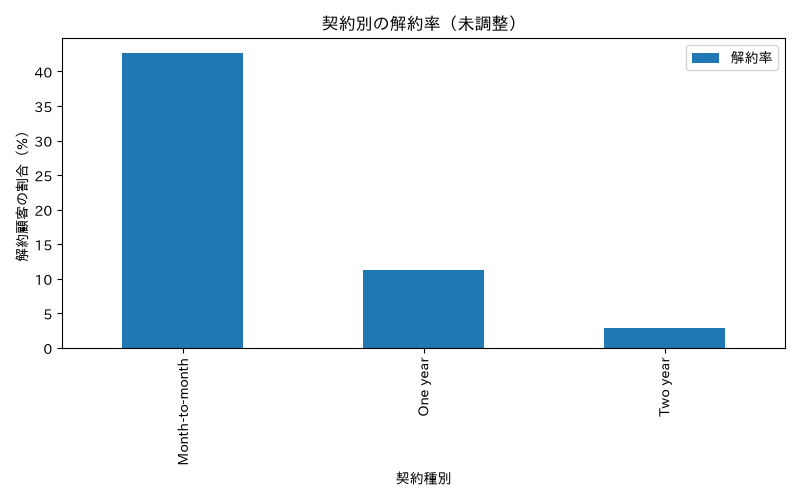

In [10]:
with phase('図1・契約別粗率'):
    import matplotlib as mpl
    chart_audits = {}
    def show_chart(role, table, kind, x, y, title, xlabel, ylabel, legend):
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter('always')
            with mpl.rc_context({'figure.autolayout': True, 'figure.figsize': (8, 5), 'font.family': 'IPAexGothic'}):
                png = visualization.render_chart(table,kind=kind,x=x,y=y,title=title,xlabel=xlabel,ylabel=ylabel)
        glyph_messages = [str(w.message) for w in caught if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
        meta = {'title':title,'xlabel':xlabel,'ylabel':ylabel,'legend':legend,'missing_glyphs':glyph_messages,'glyph_check':'render時のwarningを捕捉','notes':'率の分母・Wilson区間は対応する表に記載'}
        output = visualization.build_image_output(png)
        output['execution_count'] = (len(get_ipython().history_manager.input_hist_raw) - 1)
        def store(nb):
            cell = next(c for c in nb.cells if c.metadata.get('analysis_role') == role)
            cell.metadata['chart'] = meta
            cell['outputs'] = [output]
            cell['execution_count'] = (len(get_ipython().history_manager.input_hist_raw) - 1)
        notebook_write(store)
        chart_audits[role] = meta
        display(output.data,raw=True)
        print('図監査メタデータ:', json.dumps(meta,ensure_ascii=False))
        return png
    contract_plot = contract_rates[['Contract','rate_pct']].rename(columns={'rate_pct':'解約率'})
    png_contract = show_chart('chart1',contract_plot,'bar','Contract','解約率','契約別の解約率（未調整）','契約種別','解約顧客の割合（%）',['解約率'])


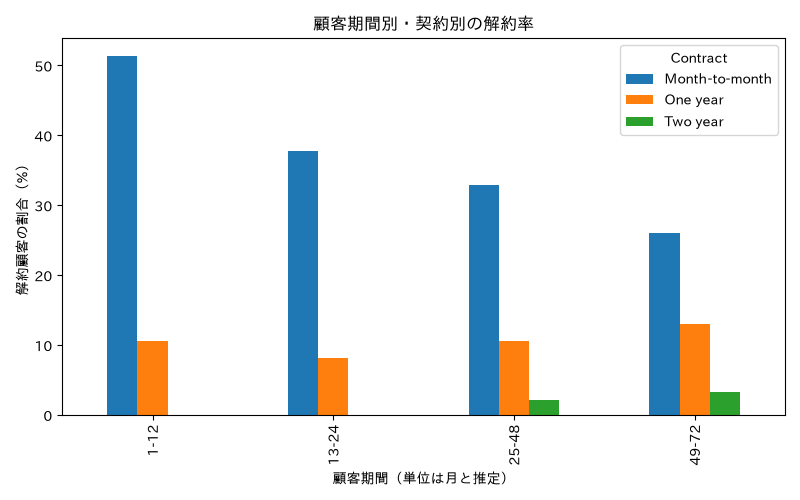

In [11]:
with phase('図2・期間と契約の層別率'):
    period_plot = rates_pivot.mul(100).reset_index()
    png_period = show_chart('chart2',period_plot,'bar','tenure_band',None,'顧客期間別・契約別の解約率','顧客期間（単位は月と推定）','解約顧客の割合（%）',list(rates_pivot.columns))


図監査メタデータ: {"title": "月額料金帯と解約率（未調整）", "xlabel": "月額料金帯（通貨は未確認）", "ylabel": "解約顧客の割合（%）", "legend": ["解約率"], "missing_glyphs": [], "glyph_check": "render時のwarningを捕捉", "notes": "率の分母・Wilson区間は対応する表に記載"}


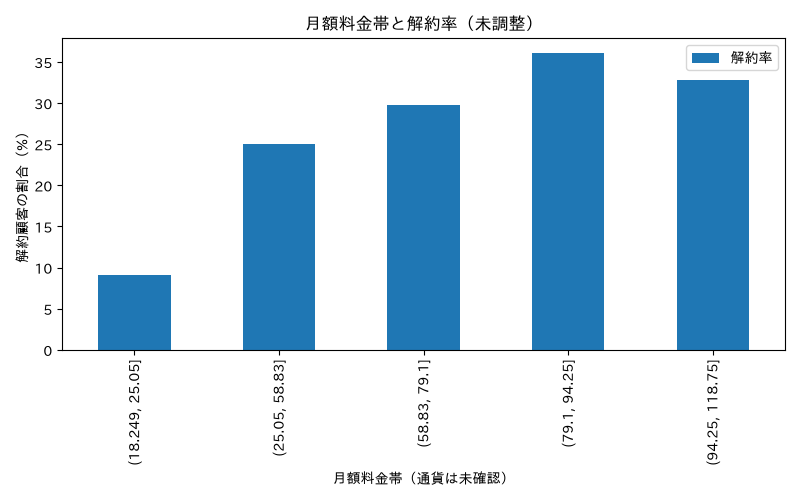

In [12]:
with phase('図3・月額料金帯の粗率'):
    fee_plot = rate_table(df,'monthly_band')[['monthly_band','rate_pct']].rename(columns={'rate_pct':'解約率'})
    fee_plot['monthly_band'] = fee_plot['monthly_band'].astype(str)
    png_fee = show_chart('chart3',fee_plot,'bar','monthly_band','解約率','月額料金帯と解約率（未調整）','月額料金帯（通貨は未確認）','解約顧客の割合（%）',['解約率'])


## Jupytermind改善候補
視覚監査で画像メタデータが存在しないケースを検査する。以下のログに分類・再現条件・期待・実際・影響・回避策・関係セルを記録する。SDKのdataset_view非対応と分析コードの冗長ダミーによる特異行列はJupytermind起因ではなく、それぞれメタデータセルと初回モデルセルのログに分離した。

In [13]:
with phase('Jupytermind視覚監査の適用限界検査'):
    probe_output = visualization.build_image_output(png_contract)
    probe_cell = nbformat.v4.new_code_cell('visualization.render_chart(...)')
    probe_cell.outputs = [probe_output]
    probe_notebook = nbformat.v4.new_notebook(cells=[probe_cell])
    probe_findings = notebook_audit.audit_visual_outputs(probe_notebook,(0,))
    probe_log = {'分類':'Jupytermind機能不足候補','再現条件':'PNG画像を含むコードセルのmetadata.chartを省略しaudit_visual_outputsを直接呼ぶ','期待する挙動':'タイトル・軸・凡例・glyph検査メタデータが未確認である所見を返す','実際の挙動':{'finding_count':len(probe_findings),'findings':[asdict(x) for x in probe_findings]},'影響':'メタデータ欠落時にvisual_auditが読みやすさ未検証を見逃す可能性。画像実内容のOCR監査ではない。','回避策':'本Notebookの全図はtitle/xlabel/ylabel/legend/missing_glyphsを明示し、renderのglyph warningを実際に捕捉。PNGは別途表示して確認。','関係するセル':'chart1/chart2/chart3と本probeセル','外部問題との切り分け':'独立したメモリ内Notebookでモジュールを直接呼び出すためCopilot CLI・Kaggle API・ランナーに依存しない。'}
    display(pd.DataFrame([probe_log]))
    print(json.dumps(probe_log,ensure_ascii=False,indent=2))
    with mpl.rc_context({'font.family': 'IPAexGothic'}):
        layout_reproduction = visualization.render_chart(contract_plot,kind='bar',x='Contract',y='解約率',title='契約別の解約率（未調整）',xlabel='契約種別',ylabel='解約顧客の割合（%）')
    layout_artifact = data_dir / 'visual-layout-default-reproduction.png'
    layout_artifact.write_bytes(layout_reproduction)
    layout_log = {'分類':'Jupytermind描画機能不足候補','再現条件':'render_chartで長いカテゴリ名を棒グラフ化。デフォルトのfigsizeとautolayout=False','期待する挙動':'PNG内に契約名とx軸タイトルが完全に収まる','実際の挙動':'初回図1で縦向きtickの下部とx軸タイトルがPNG下端に切れた（表示画像の目視確認）。再現PNGを保存。','影響':'カテゴリ名と軸の単位を読めず誤読するおそれ。visual_auditの密度・メタデータ検査だけでは検知しない。','回避策':'呼出側mpl.rc_contextでfigure.autolayout=Trueとfigsize=(8,5)。修正後3図を表示して目視確認。','関係するセル':'chart1のshow_chart、chart2、chart3、本probeセル','ログ':str(layout_artifact),'artifact_sha256':hashlib.sha256(layout_reproduction).hexdigest(),'外部問題との切り分け':'保存PNG自体のレイアウトであり、CLIやKaggleの問題ではない。ランナー非使用。'}
    print(json.dumps(layout_log,ensure_ascii=False,indent=2))
    with mpl.rc_context({'font.family':'DejaVu Sans'}):
        with warnings.catch_warnings(record=True) as captured_font:
            warnings.simplefilter('always')
            font_reproduction = visualization.render_chart(contract_plot,kind='bar',x='Contract',y='解約率',title='契約別の解約率（未調整）',xlabel='契約種別',ylabel='解約顧客の割合（%）')
    font_warnings = [str(w.message) for w in captured_font if 'Glyph' in str(w.message) and 'missing' in str(w.message)]
    font_artifact = data_dir / 'visual-font-context-reproduction.png'
    font_artifact.write_bytes(font_reproduction)
    font_context_log = {'分類':'Jupytermind日本語フォント状態不具合候補','再現条件':'日本語render_chartを一度呼んだ後、font.familyをDejaVu Sansに戻して日本語render_chartを呼ぶ。rc_context復元でも同様。','期待する挙動':'日本語が含まれる各render_chart呼出しで同梱IPAexGothicを有効化して全glyphを描画','実際の挙動':{'glyph_warning_count':len(font_warnings),'warning_sample':font_warnings[:5],'観測':'初回クリーン再実行では図1は正常、rc_context終了後の図2に日本語欠落。モジュールの一度だけの適用フラグと復元されたrcParamsが不整合。'},'影響':'冷状態での全セル再実行が文字化けし、visual_auditがmissing_glyphsを検出。数値分析結果は不変。','回避策':'各図のrc_contextにfont.family=IPAexGothicを明示。最終クリーン再実行でglyph_warningが全図0であることをassert。','関係するセル':'chart1 show_chart、chart2、本probeセル、final_auditセル','ログ':str(font_artifact),'artifact_sha256':hashlib.sha256(font_reproduction).hexdigest(),'外部問題との切り分け':'同梱フォントは登録され図1で正常表示される。モジュール直接呼出しとrcParamsの相互作用でありCLI・Kaggle・ランナー固有ではない。'}
    print(json.dumps(font_context_log,ensure_ascii=False,indent=2))


{
  "分類": "Jupytermind機能不足候補",
  "再現条件": "PNG画像を含むコードセルのmetadata.chartを省略しaudit_visual_outputsを直接呼ぶ",
  "期待する挙動": "タイトル・軸・凡例・glyph検査メタデータが未確認である所見を返す",
  "実際の挙動": {
    "finding_count": 0,
    "findings": []
  },
  "影響": "メタデータ欠落時にvisual_auditが読みやすさ未検証を見逃す可能性。画像実内容のOCR監査ではない。",
  "回避策": "本Notebookの全図はtitle/xlabel/ylabel/legend/missing_glyphsを明示し、renderのglyph warningを実際に捕捉。PNGは別途表示して確認。",
  "関係するセル": "chart1/chart2/chart3と本probeセル",
  "外部問題との切り分け": "独立したメモリ内Notebookでモジュールを直接呼び出すためCopilot CLI・Kaggle API・ランナーに依存しない。"
}
{
  "分類": "Jupytermind描画機能不足候補",
  "再現条件": "render_chartで長いカテゴリ名を棒グラフ化。デフォルトのfigsizeとautolayout=False",
  "期待する挙動": "PNG内に契約名とx軸タイトルが完全に収まる",
  "実際の挙動": "初回図1で縦向きtickの下部とx軸タイトルがPNG下端に切れた（表示画像の目視確認）。再現PNGを保存。",
  "影響": "カテゴリ名と軸の単位を読めず誤読するおそれ。visual_auditの密度・メタデータ検査だけでは検知しない。",
  "回避策": "呼出側mpl.rc_contextでfigure.autolayout=Trueとfigsize=(8,5)。修正後3図を表示して目視確認。",
  "関係するセル": "chart1のshow_chart、chart2、chart3、本probeセル",
  "ログ": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/

,分類,再現条件,期待する挙動,実際の挙動,影響,回避策,関係するセル,外部問題との切り分け
0,Jupytermind機能不足候補,PNG画像を含むコードセルのmetadata.chartを省略しaudit_visual_o...,タイトル・軸・凡例・glyph検査メタデータが未確認である所見を返す,"{'finding_count': 0, 'findings': []}",メタデータ欠落時にvisual_auditが読みやすさ未検証を見逃す可能性。画像実内容のOC...,本Notebookの全図はtitle/xlabel/ylabel/legend/missin...,chart1/chart2/chart3と本probeセル,独立したメモリ内Notebookでモジュールを直接呼び出すためCopilot CLI・Kag...


**最終報告：契約・顧客期間**
解約は26.54%であり、非解約を常に選ぶだけでもaccuracyは約73.46%になる。月次契約42.71%、1年11.27%、2年2.83%の粗解約率差があり、短期顧客の解約割合も高い。契約ごとの期間中央値が12・44・64と異なるため、期間構成を無視して契約の効果とは呼べない。期間帯内でも契約関連は残ったが、現在契約の自己選択や生存者選択を除去した因果結論ではない。tenure単位は月と推定している。

```evidence
{"execution_count":5,"cited_value":"42.709677","claim_type":"associational"}
```

**最終報告：料金と原因の区別**
高い月額は粗集計・限定調整では解約の正の予測関連を持つが、サービス構成を全て調整するとORが0.699（区間は1をまたぐ）になり、独立した料金関連は仕様に敏感。累積料金の低さも短い期間の代理であり、少ない累積料金や高月額が解約原因という解釈は支持されない。値下げ・長期契約化による解約削減効果を推定するには、契約変更前後の縦断情報、価格変動の自然実験や無作為試験、解約前の測定時点が必要。

```evidence
{"execution_count":8,"cited_value":"0.698617","claim_type":"associational"}
```

**最終報告：予測上の利用と限界**
月額はサービス構成とほぼ情報重複し、全特徴モデルでは月額を除いてもAPは0.7089→0.7087とほぼ変わらない。一方で期間除外はAPを0.6329に下げた。契約・期間はこのCSV内の顧客リスク層を記述する有用な特徴だが、特徴の重要さは因果の強さではない。クラス重み付けでrecallを高める代わりに誤警報とBrierが悪化する。収集日、対象母集団、特徴測定時点が不明なので、現実の将来月に対する性能・原因・施策効果には外挿しない。

```evidence
{"execution_count":9,"cited_value":"0.632906","claim_type":"associational"}
```

## 使用したJupytermindモジュール
直接import・直接呼び出したもののみ。略号はすべて `ai_data_scientist` のサブモジュール。可視化の内部font処理などの間接利用、未呼び出しのmcp_gateway/dataset_validation/anomaly_detectionは使用済みに含めない。

| モジュール | 直接利用した関数・型・メソッド | 使用目的 |
|---|---|---|
| project_manager | resolve_project, ensure_notebook, ensure_data_dir, enqueue_write | 保存先検証、データ置場、直列化したNotebook著者書込み |
| language_router | detect_language | 日本語判定 |
| lifecycle | register_run, mark_execution_start/end, mark_write_start/end, is_cancel_requested, mark_completed, mark_failed, get_run_status, wait_for_quiescence | run_id管理、実行・書込み区間、失敗・終了・静止確認 |
| ingestion | SourceSpec, ingest | SDK取得済みローカルCSVの読込、行数上限検査 |
| cleaning | clean_dataset | 重複検査・影響件数記録（削除0件） |
| eda | explore | dtype・要約・欠損・カテゴリ数と分布 |
| stats_analysis | correlation | 数値特徴と解約0/1、期間と累積料金のPearson相関と日本語解釈 |
| data_definition | FieldValue, build_manifest, DataDefinitionManifest.unresolved_fields | 来歴と意味定義のverified/inferred/unknown分離 |
| analysis_assumptions | Assumption, AnalysisAssumptionManifest, check_manifest | 観測関連の範囲・前提・未解決リスク |
| data_quality | detect_anomalies | 型の意味・カテゴリ・非負・一意性・欠損の制約検査 |
| sensitivity | SensitivityPlan, SensitivityPlan.specifications, run_sensitivity | 期間6仕様、料金4仕様、予測6仕様の限定感度分析 |
| visualization | render_chart, build_image_output | 日本語ラベルPNG生成と画像MIMEをenqueue_write経由で保存 |
| insight_engine | extract_cited_value, record_insight | 初回・反復・最終所見の実行済み出力照合。record_insightはNotebook作成段階のJupyter MCPオーケストレーションセルで直接呼び、再実行時は最終セルで同じ根拠値を再照合して実行番号を更新 |
| notebook_audit | audit_notebook, audit_visual_outputs | 最終実行・証拠・visual_audit=True監査、メタデータ欠落の最小再現 |

Kaggle API取得・分析コード・作成時のオーケストレーションはすべてJupyter MCP実行セル内。ターミナル・subprocess・外部スクリプト・作業エージェント・ベンチマークランナーは使用していない。Jupyter MCP自体によるセル実行出力保存を除くNotebook著者の変更はensure_notebook/enqueue_write経由。mcp_gatewayはカーネル内からの同一カーネル再入を避けるため非適用と明記した。


## 再実行・監査・ライフサイクル
最終工程でkernelを再起動し、全コードセルを上からJupyter MCPで再実行する。新しい取得時刻・SHAと出力に証拠番号を更新し、実行順を確認。最後のコードセルで全セルを含むnotebook_audit(visual_audit=True)、manifestの残る警告、completed状態・active実行/書込み/lockが0であることを出力とmetadataに保存。視覚監査の限界は改善候補に分離して記録する。

作成コードの実行番号記録にshellの次番号を使用したため最終順序検査が失敗した。IPython入力履歴の実番号へ訂正して全コードを再実行し、metadata.execution_stamp_debug_logに切り分けを記録。これはJupytermind改善候補には含めない。

In [14]:
with phase('再実行結果・証拠更新・最終監査'):
    from dataclasses import replace
    from importlib.metadata import version
    current_count = (len(get_ipython().history_manager.input_hist_raw) - 1)
    before_final = nbformat.read(handle.notebook_path,as_version=4)
    code_cells = [c for c in before_final.cells if c.cell_type == 'code']
    previous_counts = [c.execution_count for c in code_cells[:-1]]
    assert all(isinstance(c,int) for c in previous_counts), '未実行セルあり'
    assert previous_counts == sorted(set(previous_counts)), '上からの連続実行を確認できない'
    assert previous_counts == list(range(1,len(code_cells))), 'kernel再起動後の全コード上から再実行を確認できない'
    assert current_count == len(code_cells)
    final_assumptions = replace(assumptions,assumptions=tuple(replace(a,status='tested',evidence_cell=current_count,statement='期間6仕様・料金4仕様・予測6仕様で依存性を検査。料金関連は不安定と報告') if a.id == 'model-form' else a for a in assumptions.assumptions))
    assumption_findings = [asdict(x) for x in aa.check_manifest(final_assumptions)]
    print('最終前提検査所見:',json.dumps(assumption_findings,ensure_ascii=False))
    def refresh_evidence(nb):
        by_id = {c.id:c for c in nb.cells}
        refreshed = 0
        for cell in nb.cells:
            target_id = cell.metadata.get('evidence_cell_id')
            if target_id is None:
                continue
            target = by_id[target_id]
            match = re.search(r'```evidence\n(.*?)\n```',cell.source,re.S)
            manifest = json.loads(match.group(1))
            text = '\n'.join(str(o.get('data',{}).get('text/plain','')) for o in target.outputs)
            cited = insight_engine.extract_cited_value({'output':text},re.escape(str(manifest['cited_value'])))
            manifest.update(execution_count=target.execution_count,cited_value=cited)
            cell.source = cell.source[:match.start()] + '```evidence\n' + json.dumps(manifest,separators=(',',':')) + '\n```' + cell.source[match.end():]
            refreshed += 1
        assert refreshed == 8
        for cell in nb.cells:
            role = cell.metadata.get('analysis_role')
            if role in chart_audits:
                cell.metadata['chart'] = chart_audits[role]
        nb.metadata['run_id'] = RUN_ID
        nb.metadata['provenance'] = provenance
        nb.metadata['data_definition_manifest'] = json.loads(json.dumps(asdict(definition_manifest),default=str))
        nb.metadata['analysis_assumption_manifest'] = asdict(final_assumptions)
        nb.metadata['jupytermind_improvement_candidates'] = [probe_log,layout_log,font_context_log]
        nb.metadata['sensitivity_summary'] = {'period':sensitivity_reports1,'fees':asdict(fee_sensitivity),'prediction':prediction_sensitivity}
        nb.metadata['execution_route'] = 'Jupyter MCP execute_cellのみ（取得・分析・再実行）'
        nb.metadata['top_to_bottom_reexecution'] = {'kernel_restarted':True,'execution_counts':previous_counts+[current_count],'code_cell_count':len(code_cells),'verified_at_utc':datetime.now(timezone.utc).isoformat()}
        nb.metadata['environment_versions'] = {p:version(p) for p in ['kaggle','pandas','numpy','scipy','statsmodels','scikit-learn','matplotlib','nbformat']}
    notebook_write(refresh_evidence)
    audit_first = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    if not audit_first.ok:
        print('監査失敗:',asdict(audit_first))
        raise RuntimeError('Notebook監査に未解決のエラーがあります')
    # 最終セル自身の実行状態を確定し、全セルを含む監査をもう一度行う。
    def stamp_final_cell(nb):
        cell = nb.cells[-1]
        cell.execution_count = current_count
        cell.outputs = [nbformat.v4.new_output('execute_result',data={'text/plain':'最終監査中'},execution_count=current_count)]
    notebook_write(stamp_final_cell)
    audit_final = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    assert audit_final.ok and not audit_final.findings and not audit_final.visual_findings
    assert audit_final.executed_code_cell_count == audit_final.code_cell_count == len(code_cells)
    assert len(audit_final.chart_cell_indices) == 3 and audit_final.insight_cell_count == 8
    assert all(not meta['missing_glyphs'] for meta in chart_audits.values())
lifecycle.mark_completed(RUN_ID)
final_status = lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
assert final_status.state == 'completed'
assert final_status.active_cell_executions == final_status.pending_notebook_writes == final_status.locks_held == 0
final_result = {'run_id':RUN_ID,'notebook_audit':{**asdict(audit_final),'ok':audit_final.ok,'visual_audit':True},'lifecycle':asdict(final_status),'analysis_assumption_findings':assumption_findings,'data_definition_caveats':[(k,asdict(v)) for k,v in definition_manifest.unresolved_fields()]+inferred_definitions,'iteration_count':3,'visual_manual_review':'補正後3図の日本語ラベル・凡例・カテゴリ名・軸範囲をJupyter MCP表示で確認。短期2年ゼロ率と料金未調整を説明文に明記。','jupytermind_improvement_candidate_count':3,'provenance':provenance}
def persist_final_report(nb):
    nb.metadata['notebook_audit'] = final_result['notebook_audit']
    nb.metadata['lifecycle_status'] = asdict(final_status)
    nb.metadata['lifecycle_events'] = list(lifecycle_log)
    nb.cells[-1].execution_count = current_count
    nb.cells[-1].outputs = [nbformat.v4.new_output('execute_result',data={'text/plain':json.dumps(final_result,ensure_ascii=False,indent=2)},execution_count=current_count)]
notebook_write(persist_final_report)
# 作成時の一時Notebookのみを明示的に削除。分析データ・再現PNG・成果Notebookは保持。
bootstrap_path = ROOT / 'benchmark/v020-exp-43-bootstrap.ipynb'
if bootstrap_path.exists():
    bootstrap_path.unlink()
print(json.dumps(final_result,ensure_ascii=False,indent=2))
print('終了時の静止状態:',asdict(lifecycle.get_run_status(RUN_ID)))


{
  "run_id": "v020-exp-43",
  "notebook_audit": {
    "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-43-customer-churn/notebooks/kaggle-v020-kaggle-exp-43-customer-churn.ipynb",
    "nbformat_valid": true,
    "code_cell_count": 14,
    "executed_code_cell_count": 14,
    "unexecuted_cell_indices": [],
    "error_cell_indices": [],
    "chart_cell_indices": [
      24,
      25,
      26
    ],
    "insight_cell_count": 8,
    "findings": [],
    "visual_findings": [],
    "ok": true,
    "visual_audit": true
  },
  "lifecycle": {
    "run_id": "v020-exp-43",
    "state": "completed",
    "active_cell_executions": 0,
    "pending_notebook_writes": 0,
    "locks_held": 0,
    "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-43-customer-churn/notebooks/kaggle-v020-kaggle-exp-43-customer-churn.ipynb",
    "reason": null
  },
  "analysis_assumption_findings": [
    {
      "code": "unresolved_conclusion_cri